# Import libraries

In [52]:
import matplotlib.pyplot as plt
import dhnx
import pandas as pd
import oemof.solph as solph
from pyomo.environ import SolverFactory
import numpy as np

In [53]:
import shutil
print(shutil.which("cbc"))

C:\Users\axelj\miniconda3\envs\dhnx_env\Library\bin\cbc.EXE


In [54]:
import sys
import pandas as pd
import importlib.metadata as md

print("Python executable:", sys.executable)
print("Python version:", sys.version)

for package in [
    "dhnx",
    "oemof.solph",
    "oemof.network",
    "pandas",
    "pyomo",
    "numpy"
]:
    try:
        print(package, md.version(package))
    except Exception as e:
        print(package, "not found:", e)

Python executable: c:\Users\axelj\miniconda3\envs\dhnx_env\python.exe
Python version: 3.12.14 | packaged by conda-forge | (main, Sep  2 2026, 23:18:20) [MSC v.1944 64 bit (AMD64)]
dhnx 0.0.4
oemof.solph 0.6.5
oemof.network 0.5.3
pandas 3.0.6
pyomo 6.10.1
numpy 2.5.3


In [55]:
print(dhnx.__version__)
print(solph.__version__)
print("pandas:", pd.__version__)



0.0.4
0.6.5
pandas: 3.0.6


In [56]:
import sys

!"{sys.executable}" -m pip install --upgrade oemof.solph

In [57]:
import inspect
print(inspect.signature(solph.Flow))

(nominal_capacity=None, nominal_value=None, min=None, max=None, variable_costs=0, minimum=None, maximum=None, fix=None, positive_gradient_limit=None, negative_gradient_limit=None, full_load_time_max=None, full_load_time_min=None, integer=False, bidirectional=False, nonconvex=None, lifetime=None, age=None, fixed_costs=None, custom_attributes=None, custom_properties=None)


In [58]:
import sys
import oemof.solph as solph
import dhnx

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("DHNx version:", dhnx.__version__)
print("oemof.solph version:", solph.__version__)
print("oemof.solph loaded from:", solph.__file__)

help(solph.Flow)

Python executable: c:\Users\axelj\miniconda3\envs\dhnx_env\python.exe
Python version: 3.12.14 | packaged by conda-forge | (main, Sep  2 2026, 23:18:20) [MSC v.1944 64 bit (AMD64)]
DHNx version: 0.0.4
oemof.solph version: 0.6.5
oemof.solph loaded from: c:\Users\axelj\miniconda3\envs\dhnx_env\Lib\site-packages\oemof\solph\__init__.py
Help on class Flow in module oemof.solph.flows._flow:

class Flow(oemof.network.network.edge.Edge)
 |  Flow(nominal_capacity=None, nominal_value=None, min=None, max=None, variable_costs=0, minimum=None, maximum=None, fix=None, positive_gradient_limit=None, negative_gradient_limit=None, full_load_time_max=None, full_load_time_min=None, integer=False, bidirectional=False, nonconvex=None, lifetime=None, age=None, fixed_costs=None, custom_attributes=None, custom_properties=None)
 |
 |  Defines a flow between two nodes.
 |
 |  Keyword arguments are used to set the attributes of this flow. Parameters
 |  which are handled specially are noted below.
 |  For the cas

# [Introduction](https://github.com/oemof/DHNx/tree/dev/examples/optimisation/introduction)

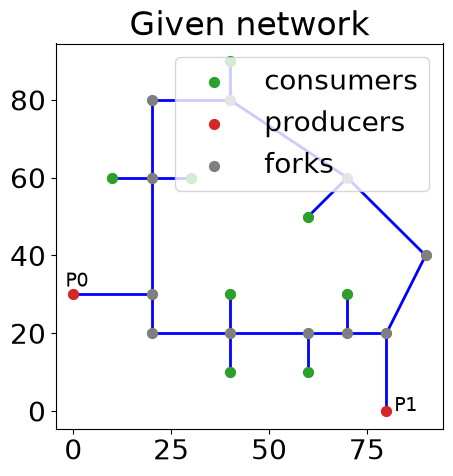

In [59]:
# Initialize thermal network
network = dhnx.network.ThermalNetwork()

# Load town parameter
network = network.from_csv_folder(r"C:\Users\axelj\Documents\Project 2 - MJ2505\DNHx Tutorial\introduction\twn_data")

# Load investment parameter
invest_opt = dhnx.input_output.load_invest_options(r"C:\Users\axelj\Documents\Project 2 - MJ2505\DNHx Tutorial\introduction\invest_data")

# plot initial/given network
static_map = dhnx.plotting.StaticMap(network) # That's how DHNx plots the network
static_map.draw(background_map=False) # This line to show the network on a blank area.
plt.title('Given network') 

#Scatter plots to differentiate the consumers, producers and forks. 
plt.scatter(network.components.consumers['lon'], network.components.consumers['lat'],
            color='tab:green', label='consumers', zorder=2.5, s=50) 
plt.scatter(network.components.producers['lon'], network.components.producers['lat'],
            color='tab:red', label='producers', zorder=2.5, s=50)
plt.scatter(network.components.forks['lon'], network.components.forks['lat'],
            color='tab:grey', label='forks', zorder=2.5, s=50)
plt.text(-2, 32, 'P0', fontsize=14)
plt.text(82, 0, 'P1', fontsize=14)
plt.legend()
plt.show()

INFO:dhnx.optimization.optimization_models:Initialize the energy system
INFO:dhnx.optimization.optimization_models:Create oemof objects
INFO:dhnx.optimization.optimization_models:Producers, Consumers Nodes appended.
INFO:dhnx.optimization.optimization_models:DHS Nodes appended.
INFO:dhnx.optimization.optimization_models:Energysystem has been created
INFO:dhnx.optimization.optimization_models:Build the operational model
INFO:dhnx.optimization.optimization_models:Solve the optimization problem


Welcome to the CBC MILP Solver 
Version: 2.10.13 
Build Date: May 12 2026 

command line - C:\Users\axelj\miniconda3\envs\dhnx_env\Library\bin\cbc.exe -printingOptions all -import C:\Users\axelj\AppData\Local\Temp\tmplg_9xrab.pyomo.lp -stat=1 -solve -solu C:\Users\axelj\AppData\Local\Temp\tmplg_9xrab.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
Presolve 59 (-186) rows, 56 (-170) columns and 172 (-374) elements
Statistics for presolved model


Problem has 59 rows, 56 columns (32 with objective) and 172 elements
There are 8 singletons with objective 
Column breakdown:
24 of type 0.0->inf, 24 of type 0.0->up, 0 of type lo->inf, 
8 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 0 of type 0.0->1.0 
Row breakdown:
5 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
6 of type E other, 0 of type G 0.0, 0 of type G 1.0, 
0 of type G other, 48 of type L 0.0, 0 of type L 1.0, 
0 of type L other, 0 of type Range 

INFO:root:Optimization successful.


      from_node      to_node     hp_type    capacity  direction       costs  \
id                                                                            
0   producers-0      forks-0  pipe-typ-A  115.072630          1  4602.90520   
1   producers-1      forks-5  pipe-typ-A   86.049421          1  3441.97684   
2       forks-0      forks-1  pipe-typ-A   33.013204          1   660.26408   
3       forks-1      forks-2  pipe-typ-A   33.009902          1  1320.39608   
4       forks-2      forks-3        None    0.000000          0     0.00000   
5       forks-3      forks-4  pipe-typ-A   25.005001         -1   500.10002   
6       forks-4      forks-5  pipe-typ-A   61.014703         -1  1220.29406   
7       forks-5      forks-6  pipe-typ-A   25.017509          1  1501.05054   
8       forks-6      forks-7  pipe-typ-A   25.010003          1  1500.60018   
9       forks-7      forks-8        None    0.000000          0     0.00000   
10      forks-8      forks-9  pipe-typ-A   12.003601

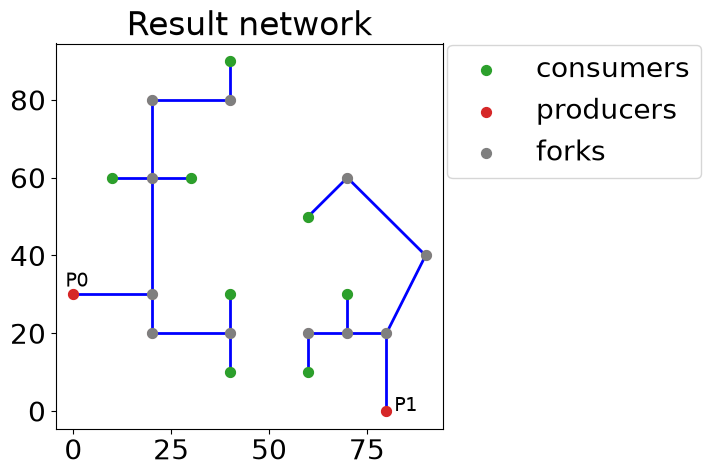

In [60]:
# Optimize the investment data
network.optimize_investment(invest_options=invest_opt,  solver='cbc')
plt.rcParams['font.size'] = 20             # enlarge all text (titles, labels, ticks)

# The data is is a dictionary composed of oemof, oemof_meta and components.
#- The oemof shows the energy flows as in oemof.solph.
#- The oemof_meta shows the optimization number of variables, constraints and objective function value.
#- The components has all pipe connection and details.
#We are particulary concerned about the connection from what node to what node, type of the pipe,
#capacity of the pipe, direction, costs and losses. 

# ####### Postprocessing and Plotting ###########
# get results
results_edges = network.results.optimization['components']['pipes']
results_edges
print(results_edges[['from_node', 'to_node', 'hp_type', 'capacity',
                     'direction', 'costs', 'losses']])

# print(results_edges[['invest_costs[€]']].sum())
print('Objective value: ', network.results.optimization['oemof_meta']['objective'])

# assign new ThermalNetwork with invested pipes
twn_results = network
twn_results.components['pipes'] = results_edges[results_edges['capacity'] > 0.001]

# plot invested edges
static_map_2 = dhnx.plotting.StaticMap(twn_results)
static_map_2.draw(background_map=False)
plt.title('Result network')
plt.scatter(network.components.consumers['lon'], network.components.consumers['lat'],
            color='tab:green', label='consumers', zorder=2.5, s=50)
plt.scatter(network.components.producers['lon'], network.components.producers['lat'],
            color='tab:red', label='producers', zorder=2.5, s=50)
plt.scatter(network.components.forks['lon'], network.components.forks['lat'],
            color='tab:grey', label='forks', zorder=2.5, s=50)
plt.text(-2, 32, 'P0', fontsize=14)
plt.text(82, 0, 'P1', fontsize=14)
plt.legend(loc=(1.01,0.65))
plt.show()

In [61]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\axelj\miniconda3\envs\dhnx_env\python.exe
3.12.14 | packaged by conda-forge | (main, Sep  2 2026, 23:18:20) [MSC v.1944 64 bit (AMD64)]


# [minimal_network](https://github.com/oemof/DHNx/tree/dev/examples/optimisation/minimal_network)

INFO:dhnx.optimization.optimization_models:Initialize the energy system
INFO:dhnx.optimization.optimization_models:Create oemof objects
INFO:dhnx.optimization.optimization_models:Producers, Consumers Nodes appended.
INFO:dhnx.optimization.optimization_models:DHS Nodes appended.
INFO:dhnx.optimization.optimization_models:Energysystem has been created
INFO:dhnx.optimization.optimization_models:Build the operational model
INFO:dhnx.optimization.optimization_models:Solve the optimization problem


No sequences found to create timeindex from
Welcome to the CBC MILP Solver 
Version: 2.10.13 
Build Date: May 12 2026 

command line - C:\Users\axelj\miniconda3\envs\dhnx_env\Library\bin\cbc.exe -printingOptions all -import C:\Users\axelj\AppData\Local\Temp\tmpt6y_bxkw.pyomo.lp -stat=1 -solve -solu C:\Users\axelj\AppData\Local\Temp\tmpt6y_bxkw.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
Presolve 3 (-73) rows, 8 (-63) columns and 14 (-147) elements
Statistics for presolved model


Problem has 3 rows, 8 columns (8 with objective) and 14 elements
There are 2 singletons with objective 
Column breakdown:
0 of type 0.0->inf, 8 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 0 of type 0.0->1.0 
Row breakdown:
1 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
2 of type E other, 0 of type G 0.0, 0 of type G 1.0, 
0 of type G other, 0 of type L 0.0, 0 of type L 1.0, 
0 o

INFO:root:Optimization successful.
INFO:dhnx.optimization.optimization_models:Store lp-file in C:\Users\axelj\.oemof\lp_files\DHNx.lp


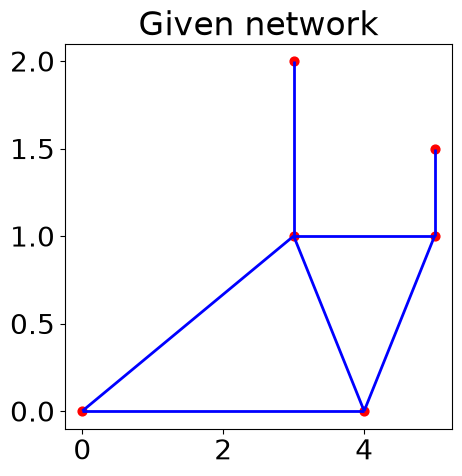

*Results*
      from_node      to_node  length     hp_type  capacity  direction   costs  \
id                                                                              
0   producers-0      forks-0   4.000        None       0.0          0   0.000   
1   producers-0      forks-1   3.162  pipe-typ-A      33.0          1  52.173   
5       forks-0      forks-1   1.414        None       0.0          0   0.000   
6       forks-0      forks-2   1.414        None       0.0          0   0.000   
9       forks-1      forks-2   1.000  pipe-typ-A      18.0          1   9.000   
10      forks-1  consumers-0   1.000  pipe-typ-A      15.0          1   7.500   
12      forks-2  consumers-1   0.500  pipe-typ-A      18.0          1   4.500   

    losses  
id          
0      0.0  
1      0.0  
5      0.0  
6      0.0  
9      0.0  
10     0.0  
12     0.0  

Objective Value:  73.1730000000013
Costs re-calculation:  73.173


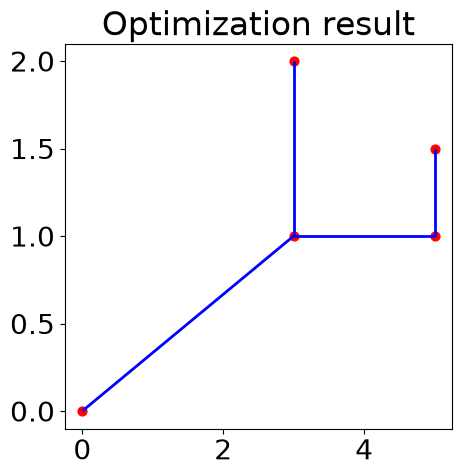

In [62]:
# Initialize thermal network
network = dhnx.network.ThermalNetwork()

# Load town data file for town parameters
network = network.from_csv_folder(r"C:\Users\axelj\Documents\Project 2 - MJ2505\DNHx Tutorial\minimal network\twn_data")

# Load investment parameter
invest_opt = dhnx.input_output.load_invest_options(r"C:\Users\axelj\Documents\Project 2 - MJ2505\DNHx Tutorial\minimal network\invest_data")

# Execute investment optimization
network.optimize_investment(invest_options=invest_opt, write_lp_file=True, solver='cbc')

# ####### Postprocessing and Plotting ###########
# Draw network
static_map = dhnx.plotting.StaticMap(network)
static_map.draw(background_map=False)
plt.title("Given network")
plt.show()

# get results
results_edges = network.results.optimization["components"]["pipes"]
print("*Results*")
print(results_edges)
print("")
print("Objective Value: ", network.results.optimization["oemof_meta"]["objective"])

# manually recalculate total costs
total_costs = (33 * 3.162 + 15 * 1 + 18 * 1 + 18 * 0.5) * 0.5
print("Costs re-calculation: ", total_costs)

# get indices which are existing or invested
ind = results_edges[results_edges["capacity"] > 0].index

# select invested edges
network_result = network
network_result.components["pipes"] = results_edges.loc[ind]

# plot results network
static_map = dhnx.plotting.StaticMap(network_result)
static_map.draw(background_map=False)
plt.title("Optimization result")
plt.show()

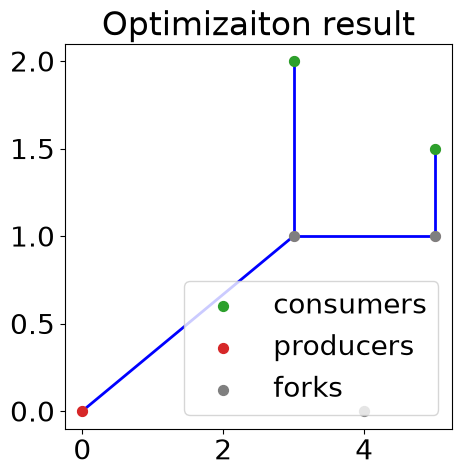

In [63]:
static_map = dhnx.plotting.StaticMap(network)
static_map.draw(background_map=False)
plt.title('Optimizaiton result')
plt.scatter(network.components.consumers['lon'], network.components.consumers['lat'],
            color='tab:green', label='consumers', zorder=2.5, s=50)
plt.scatter(network.components.producers['lon'], network.components.producers['lat'],
            color='tab:red', label='producers', zorder=2.5, s=50)
plt.scatter(network.components.forks['lon'], network.components.forks['lat'],
            color='tab:grey', label='forks', zorder=2.5, s=50)
plt.legend()
plt.show()

# [discrete_DN_numbers](https://github.com/oemof/DHNx/tree/dev/examples/optimisation/discrete_DN_numbers)


Discrete DN number examples.

This example shows how to perform an optimisation with an investment in discrete DN numbers.

Please see the `pipes.csv` in the invest_data/network.

For each of the DN numbers a separate row is given in the table.


INFO:dhnx.optimization.optimization_models:Initialize the energy system
INFO:dhnx.optimization.optimization_models:Create oemof objects
INFO:dhnx.optimization.optimization_models:Producers, Consumers Nodes appended.
INFO:dhnx.optimization.optimization_models:DHS Nodes appended.


No sequences found to create timeindex from


INFO:dhnx.optimization.optimization_models:Energysystem has been created
INFO:dhnx.optimization.optimization_models:Build the operational model
INFO:dhnx.optimization.optimization_models:Solve the optimization problem


String of cbc.log is illegal for integer parameter logLevel value remains 1
Statistics for presolved model
Original problem has 155 integers (155 of which binary)
Presolved problem has 155 integers (155 of which binary)
==== 310 zero objective 16 different
==== absolute objective values 16 different
==== for integers 0 zero objective 15 different
==== for integers absolute objective values 15 different
===== end objective counts


Problem has 639 rows, 465 columns (155 with objective) and 1850 elements
Column breakdown:
155 of type 0.0->inf, 155 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 155 of type 0.0->1.0 
Row breakdown:
11 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
8 of type E other, 0 of type G 0.0, 0 of type G 1.0, 
0 of type G other, 620 of type L 0.0, 0 of type L 1.0, 
0 of type L other, 0 of type Range 0.0->1.0, 0 of type Range other, 
0 of type Free 
Cgl0003I 0 fixed, 0 tightened bo

INFO:root:Optimization successful.


      from_node      to_node hp_type  capacity  direction    costs    losses
id                                                                          
0   producers-0      forks-0   DN-63     335.0          1  12400.0  0.228250
2       forks-0      forks-1   DN-40      98.0          1   5220.0  0.095755
3       forks-1      forks-2   DN-40      98.0          1  10440.0  0.191510
4       forks-2      forks-3   DN-40      98.0          1  10440.0  0.191510
5       forks-3      forks-4   DN-32      54.0          1   4910.0  0.086405
6       forks-4      forks-5    None       0.0          0      0.0  0.000000
7       forks-5      forks-6    None       0.0          0      0.0  0.000000
8       forks-6      forks-7    None       0.0          0      0.0  0.000000
9       forks-7      forks-8   DN-25      28.0         -1  13980.0  0.229680
10      forks-8      forks-9   DN-32      54.0         -1   9820.0  0.172810
11      forks-9     forks-10   DN-32      54.0         -1   4910.0  0.086405

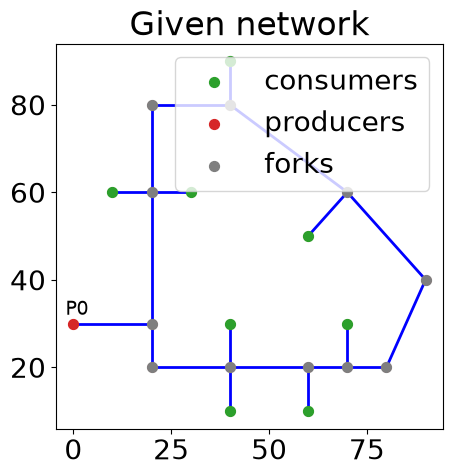

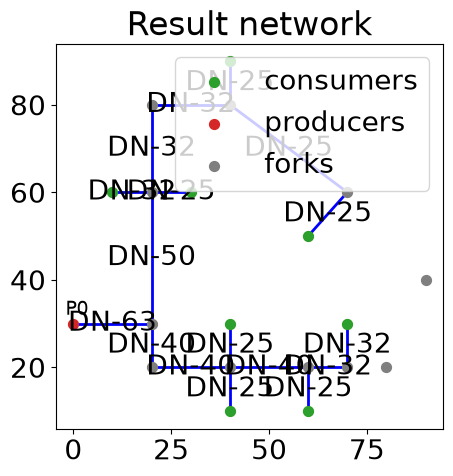

In [64]:


# Initialize thermal network
network = dhnx.network.ThermalNetwork()
# Load town paramters
network = network.from_csv_folder(r"C:\Users\axelj\Documents\Project 2 - MJ2505\DNHx Tutorial\discrete_DN_numbers\Case 1\twn_data")

# Load investment parameter
invest_opt = dhnx.input_output.load_invest_options(r"C:\Users\axelj\Documents\Project 2 - MJ2505\DNHx Tutorial\discrete_DN_numbers\Case 1\invest_data")

# plot network
static_map = dhnx.plotting.StaticMap(network)
static_map.draw(background_map=False)
plt.title("Given network")
plt.scatter(
    network.components.consumers["lon"],
    network.components.consumers["lat"],
    color="tab:green",
    label="consumers",
    zorder=2.5,
    s=50,
)
plt.scatter(
    network.components.producers["lon"],
    network.components.producers["lat"],
    color="tab:red",
    label="producers",
    zorder=2.5,
    s=50,
)
plt.scatter(
    network.components.forks["lon"],
    network.components.forks["lat"],
    color="tab:grey",
    label="forks",
    zorder=2.5,
    s=50,
)
plt.text(-2, 32, "P0", fontsize=14)
plt.legend()

# Execute investment optimization
network.optimize_investment(invest_options=invest_opt, solver='cbc',solver_cmdline_options={'maxNodes': 2000, 'log': 'cbc.log'})

# ####### Postprocessing and Plotting ###########

# get results
results_edges = network.results.optimization["components"]["pipes"]
print(
    results_edges[
        ["from_node", "to_node", "hp_type", "capacity", "direction", "costs", "losses"]
    ]
)

# print(results_edges[['invest_costs[€]']].sum())
print("Objective value: ", network.results.optimization["oemof_meta"]["objective"])

# assign new ThermalNetwork with invested pipes
twn_results = network
twn_results.components["pipes"] = results_edges[results_edges["capacity"] > 0.001]

# plot invested edges
static_map_2 = dhnx.plotting.StaticMap(twn_results)
static_map_2.draw(background_map=False)
plt.title("Result network")
plt.scatter(
    network.components.consumers["lon"],
    network.components.consumers["lat"],
    color="tab:green",
    label="consumers",
    zorder=2.5,
    s=50,
)
plt.scatter(
    network.components.producers["lon"],
    network.components.producers["lat"],
    color="tab:red",
    label="producers",
    zorder=2.5,
    s=50,
)
plt.scatter(
    network.components.forks["lon"],
    network.components.forks["lat"],
    color="tab:grey",
    label="forks",
    zorder=2.5,
    s=50,
)
plt.text(-2, 32, "P0", fontsize=14)
for r, c in twn_results.components["pipes"].iterrows():
    size = c["hp_type"]
    type = c["from_node"].split("-")[0]
    id = c["from_node"].split("-")[1]
    lat_0 = twn_results.components[type].loc[id].lat
    lon_0 = twn_results.components[type].loc[id].lon
    type = c["to_node"].split("-")[0]
    id = c["to_node"].split("-")[1]
    lat_1 = twn_results.components[type].loc[id].lat
    lon_1 = twn_results.components[type].loc[id].lon
    lat_mid = lat_0 + 0.5 * (lat_1 - lat_0)
    lon_mid = lon_0 + 0.5 * (lon_1 - lon_0)
    plt.text(lon_mid, lat_mid, size, va="center", ha="center")

plt.legend()
plt.show()

# Same as example 2 but with different pipes

INFO:dhnx.optimization.optimization_models:Initialize the energy system
INFO:dhnx.optimization.optimization_models:Create oemof objects
INFO:dhnx.optimization.optimization_models:Producers, Consumers Nodes appended.
INFO:dhnx.optimization.optimization_models:DHS Nodes appended.
INFO:dhnx.optimization.optimization_models:Energysystem has been created
INFO:dhnx.optimization.optimization_models:Build the operational model
INFO:dhnx.optimization.optimization_models:Solve the optimization problem


Welcome to the CBC MILP Solver 
Version: 2.10.13 
Build Date: May 12 2026 

command line - C:\Users\axelj\miniconda3\envs\dhnx_env\Library\bin\cbc.exe -printingOptions all -import C:\Users\axelj\AppData\Local\Temp\tmpm__7_jtf.pyomo.lp -stat=1 -solve -solu C:\Users\axelj\AppData\Local\Temp\tmpm__7_jtf.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
Presolve 205 (-251) rows, 150 (-251) columns and 580 (-471) elements
Statistics for presolved model
Original problem has 50 integers (50 of which binary)
Presolved problem has 50 integers (50 of which binary)
==== 100 zero objective 26 different
==== absolute objective values 26 different
==== for integers 0 zero objective 25 different
==== for integers absolute objective values 25 different
===== end objective counts


Problem has 205 rows, 150 columns (50 with objective) and 580 elements
Column breakdown:
50 of type 0.0->inf, 50 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type free, 0 of

INFO:root:Optimization successful.


      from_node      to_node hp_type  capacity  direction     costs    losses
id                                                                           
0   producers-0      forks-0    None       0.0          0     0.000  0.000000
1   producers-0      forks-1   DN-32      54.0          1  1552.542  0.027193
5       forks-0      forks-1    None       0.0          0     0.000  0.000000
6       forks-0      forks-2    None       0.0          0     0.000  0.000000
9       forks-1      forks-2   DN-25      28.0          1   466.000  0.007656
10      forks-1  consumers-0   DN-25      27.0          1   466.000  0.007656
12      forks-2  consumers-1   DN-25      27.0          1   233.000  0.003828
Objective value:  2717.542


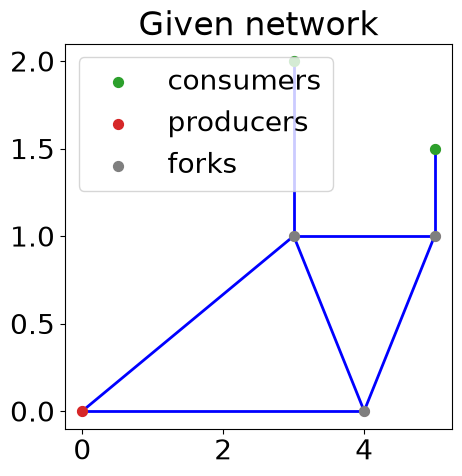

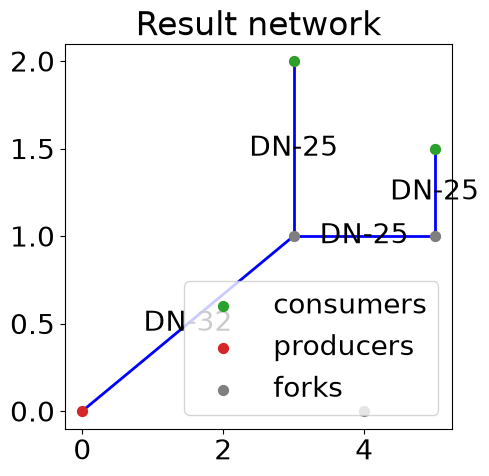

In [66]:
# Initialize thermal network
network = dhnx.network.ThermalNetwork()

# Load town paramters
network = network.from_csv_folder(r"C:\Users\axelj\Documents\Project 2 - MJ2505\DNHx Tutorial\discrete_DN_numbers\Case 2\twn_data")

# Load investment parameter
invest_opt = dhnx.input_output.load_invest_options(r"C:\Users\axelj\Documents\Project 2 - MJ2505\DNHx Tutorial\discrete_DN_numbers\Case 2\invest_data")

# plot network
static_map = dhnx.plotting.StaticMap(network)
static_map.draw(background_map=False)
plt.title("Given network")
plt.scatter(
    network.components.consumers["lon"],
    network.components.consumers["lat"],
    color="tab:green",
    label="consumers",
    zorder=2.5,
    s=50,
)
plt.scatter(
    network.components.producers["lon"],
    network.components.producers["lat"],
    color="tab:red",
    label="producers",
    zorder=2.5,
    s=50,
)
plt.scatter(
    network.components.forks["lon"],
    network.components.forks["lat"],
    color="tab:grey",
    label="forks",
    zorder=2.5,
    s=50,
)
# plt.text(-2, 32, "P0", fontsize=14)
plt.legend()

# Execute investment optimization
network.optimize_investment(invest_options=invest_opt, solver='cbc')

# ####### Postprocessing and Plotting ###########

# get results
results_edges = network.results.optimization["components"]["pipes"]
print(
    results_edges[
        ["from_node", "to_node", "hp_type", "capacity", "direction", "costs", "losses"]
    ]
)

# print(results_edges[['invest_costs[€]']].sum())
print("Objective value: ", network.results.optimization["oemof_meta"]["objective"])

# assign new ThermalNetwork with invested pipes
twn_results = network
twn_results.components["pipes"] = results_edges[results_edges["capacity"] > 0.001]

# plot invested edges
static_map_2 = dhnx.plotting.StaticMap(twn_results)
static_map_2.draw(background_map=False)
plt.title("Result network")
plt.scatter(
    network.components.consumers["lon"],
    network.components.consumers["lat"],
    color="tab:green",
    label="consumers",
    zorder=2.5,
    s=50,
)
plt.scatter(
    network.components.producers["lon"],
    network.components.producers["lat"],
    color="tab:red",
    label="producers",
    zorder=2.5,
    s=50,
)
plt.scatter(
    network.components.forks["lon"],
    network.components.forks["lat"],
    color="tab:grey",
    label="forks",
    zorder=2.5,
    s=50,
)
# plt.text(-2, 32, "P0", fontsize=14)
for r, c in twn_results.components["pipes"].iterrows():
    size = c["hp_type"]
    type = c["from_node"].split("-")[0]
    id = c["from_node"].split("-")[1]
    lat_0 = twn_results.components[type].loc[id].lat
    lon_0 = twn_results.components[type].loc[id].lon
    type = c["to_node"].split("-")[0]
    id = c["to_node"].split("-")[1]
    lat_1 = twn_results.components[type].loc[id].lat
    lon_1 = twn_results.components[type].loc[id].lon
    lat_mid = lat_0 + 0.5 * (lat_1 - lat_0)
    lon_mid = lon_0 + 0.5 * (lon_1 - lon_0)
    plt.text(lon_mid, lat_mid, size, va="center", ha="center")

plt.legend()
plt.show()